In [140]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re



In [141]:

file_k = "./data/1Hz_Delta125/100patients/k5_l3/k-anonymity_k5_l3_d125_beta50000_zeta10000_mu100.csv"
file_l = "./data/1Hz_Delta125/100patients/k5_l3/l-diversity_k5_l3_d125_beta50000_zeta10000_mu100.csv"

def parse_config(filename):
    parts = filename.replace(".csv", "").split('_')
    params = {}
    for part in parts:
        if re.match(r"^k\d+$", part):
            params["k"] = int(part[1:])
        elif re.match(r"^l\d+$", part):
            params["l"] = int(part[1:])
        elif re.match(r"^d\d+$", part):
            params["d"] = int(part[1:])
        elif part.startswith("beta"):
            params["beta"] = int(part[4:])
        elif part.startswith("zeta"):
            params["zeta"] = int(part[4:])
        elif part.startswith("mu"):
            params["mu"] = int(part[2:])
    return params

params_k = parse_config(file_k)
params_l = parse_config(file_l)

print(params_k)
print(params_l)

file_latency = "./data/1Hz_Delta125/100patients/k5_l3/Latency_k5_l3_d125_beta50000_zeta10000_mu100.csv"

df_k = pd.read_csv(file_k)
df_l = pd.read_csv(file_l)
df_latency = pd.read_csv(file_latency)


{'k': 5, 'l': 3, 'd': 125, 'beta': 50000, 'zeta': 10000, 'mu': 100}
{'k': 5, 'l': 3, 'd': 125, 'beta': 50000, 'zeta': 10000, 'mu': 100}


In [142]:

df_k["Time"] = pd.to_datetime(df_k["Time"])
df_l["Time"] = pd.to_datetime(df_l["Time"])
df_latency["Time"] = pd.to_datetime(df_latency["Time"])

def convert_latency_to_seconds(value):
    # already numeric or NaN → return as-is (assume seconds)
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)

    s = str(value).strip().lower()  # normalize
    # handle units; works with/without a space (e.g., "52.7 s", "541 ms", "1.08 mins")
    if s.endswith("mins") or s.endswith("min"):
        num = float(s.split()[0])
        return num * 60
    if s.endswith("ms"):
        num = float(s.split()[0])
        return num / 1000
    if s.endswith("s"):
        num = float(s.split()[0])
        return num
    return np.nan

df_latency["Baseline Latency"] = df_latency["Baseline Latency"].apply(convert_latency_to_seconds)
df_latency["Prink Latency"] = df_latency["Prink Latency"].apply(convert_latency_to_seconds)
df_latency["Latency Impact"] = df_latency["Prink Latency"] - df_latency["Baseline Latency"]

# Normalize time to elapsed seconds and minutes
start_time = df_k["Time"].min()
normalize_time = lambda df: (df["Time"] - start_time).dt.total_seconds()

df_k["Elapsed Seconds"] = normalize_time(df_k)
df_l["Elapsed Seconds"] = normalize_time(df_l)
df_latency["Elapsed Seconds"] = normalize_time(df_latency)

df_k["Elapsed Minutes"] = df_k["Elapsed Seconds"] / 60
df_l["Elapsed Minutes"] = df_l["Elapsed Seconds"] / 60
df_latency["Elapsed Minutes"] = df_latency["Elapsed Seconds"] / 60

# Warm-up phase tagging (first 5 minutes)
warmup_threshold = 300
warmup_minutes = warmup_threshold / 60

# Cut off data past 25 minutes
df_k = df_k[df_k["Elapsed Minutes"] <= 25]
df_l = df_l[df_l["Elapsed Minutes"] <= 25]
df_latency = df_latency[df_latency["Elapsed Minutes"] <= 25]

df_k["Warmup"] = df_k["Elapsed Seconds"] <= warmup_threshold
df_l["Warmup"] = df_l["Elapsed Seconds"] <= warmup_threshold
df_latency["Warmup"] = df_latency["Elapsed Seconds"] <= warmup_threshold


KeyError: 'Baseline Latency'

In [ ]:
def plot_with_warmup_minutes_defined(x, y, y_label, title, defined=None, color='blue'):
    plt.figure(figsize=(25, 15))
    plt.plot(x, y, label=y_label, color=color)
    if defined is not None:
        plt.plot(x, defined, label=f"Defined {y_label.split()[1]}", linestyle="--")
    plt.axvspan(0, warmup_minutes, color='orange', alpha=0.3, label="Warm-up Phase (0-5 min)")
    plt.title(title, fontsize=28)
    # smaller subtitle including parameters
    k = params_k.get("k", "N/A")
    l = params_k.get("l", "N/A")
    d = params_k.get("d", "N/A")
    beta = params_k.get("beta", "N/A")
    zeta = params_k.get("zeta", "N/A")
    mu = params_k.get("mu", "N/A")
    plt.suptitle(f"k={k}, l={l}, delta={d}, beta={beta}, zeta={zeta}, mu={mu}", fontsize=20)
    plt.xlabel("Elapsed Time (minutes)", fontsize=24)
    plt.ylabel(y_label, fontsize=24)
    plt.legend(fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

def plot_with_warmup_minutes(x, y, y_label, title, baseline=None, color='blue'):
    plt.figure(figsize=(25, 15))
    plt.plot(x, y, label=y.name if hasattr(y, "name") else y_label, color=color)
    if baseline is not None:
        plt.plot(x, baseline, label=f"Baseline {y_label.split()[1]}", linestyle="--")
    plt.axvspan(0, warmup_minutes, color='orange', alpha=0.3, label="Warm-up Phase (0-5 min)")
    plt.title(title, fontsize=28)
    # smaller subtitle including parameters
    k = params_k.get("k", "N/A")
    l = params_k.get("l", "N/A")
    d = params_k.get("d", "N/A")
    beta = params_k.get("beta", "N/A")
    zeta = params_k.get("zeta", "N/A")
    mu = params_k.get("mu", "N/A")
    plt.suptitle(f"k={k}, l={l}, delta={d}, beta={beta}, zeta={zeta}, mu={mu}", fontsize=20)
    plt.xlabel("Elapsed Time (minutes)", fontsize=24)
    plt.ylabel(y_label, fontsize=24)
    plt.legend(fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()


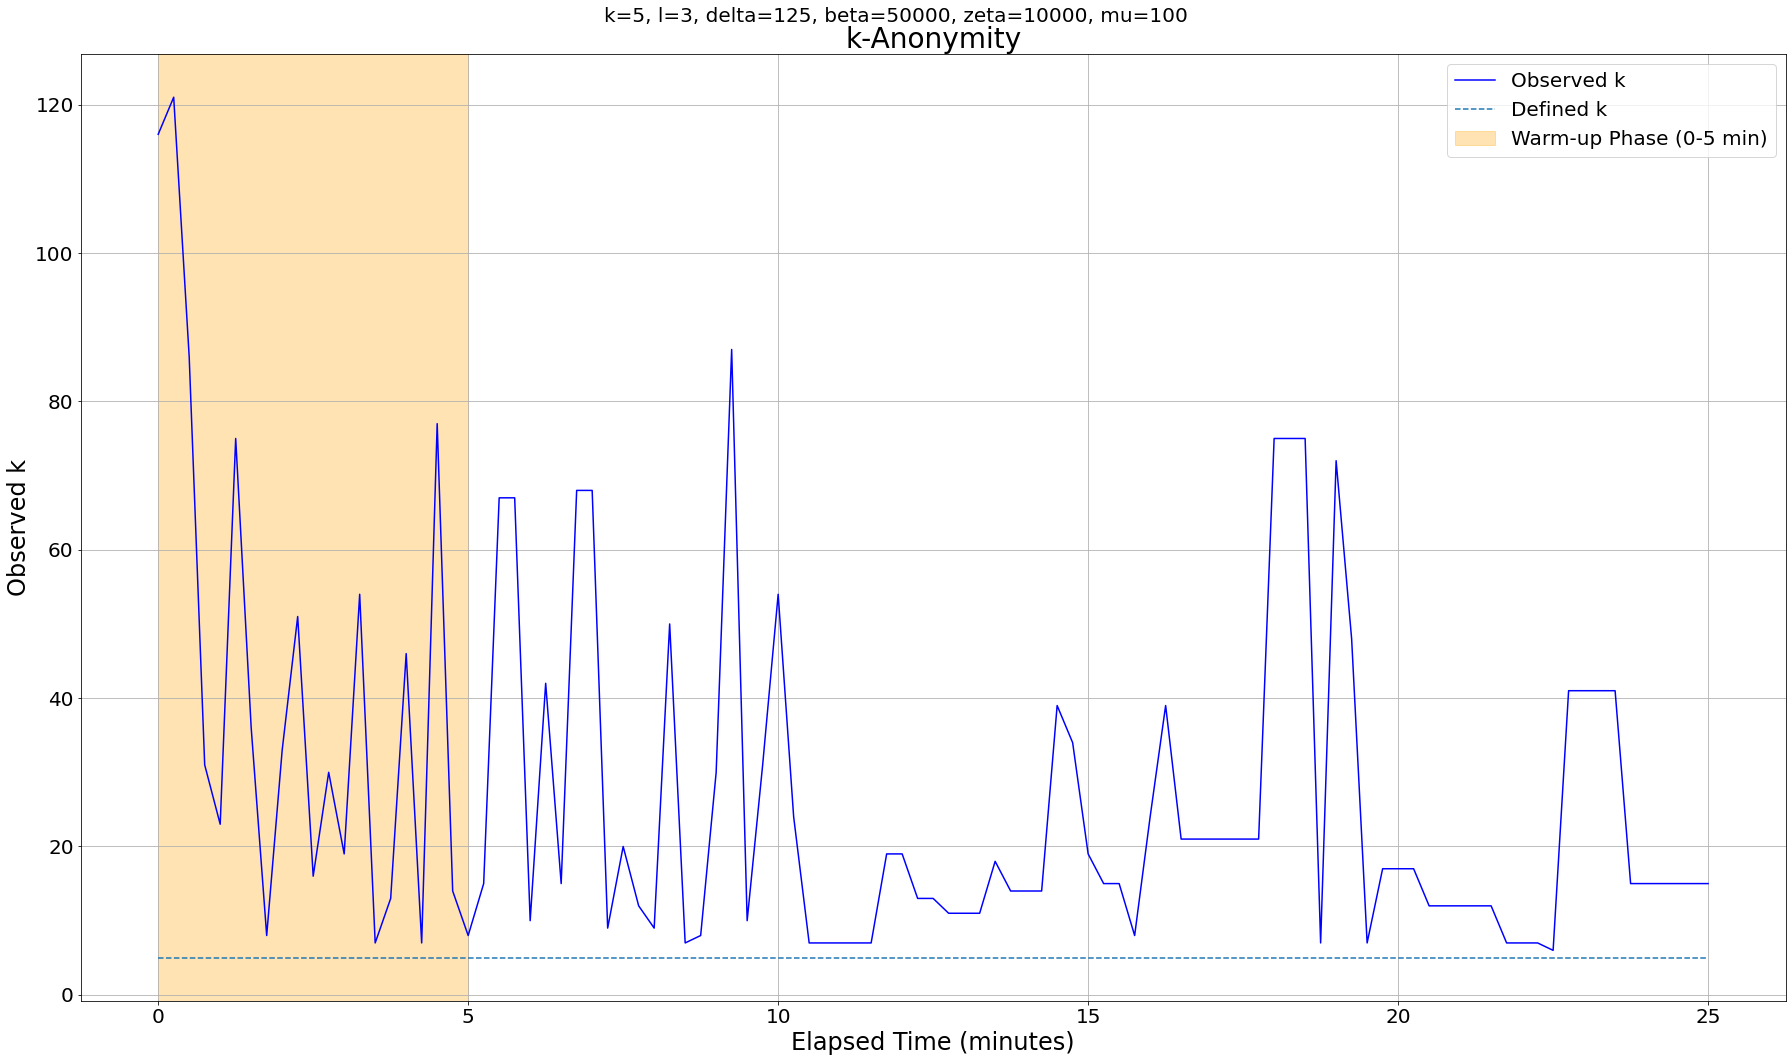

In [ ]:

plot_with_warmup_minutes_defined(df_k["Elapsed Minutes"], df_k["Observed k"], "Observed k", "k-Anonymity", defined=df_k["Defined k"])


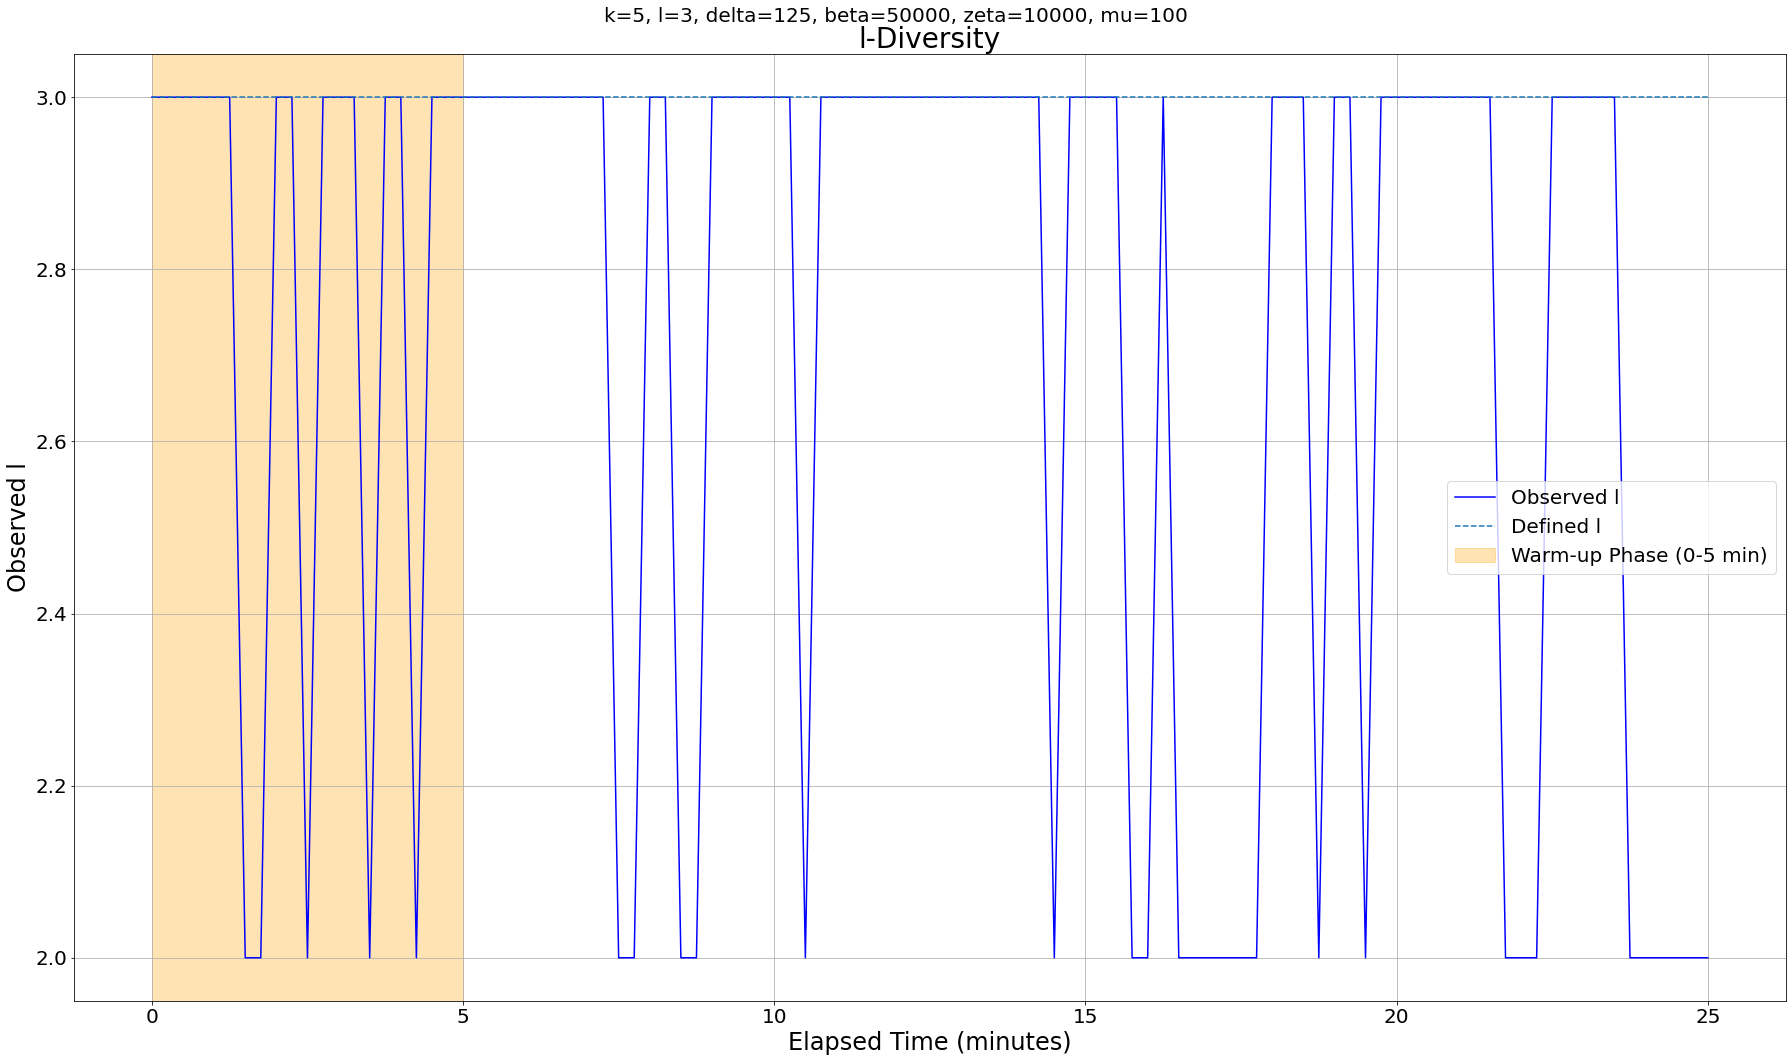

In [ ]:

plot_with_warmup_minutes_defined(df_l["Elapsed Minutes"], df_l["Observed l"], "Observed l", "l-Diversity", defined=df_l["Defined l"])


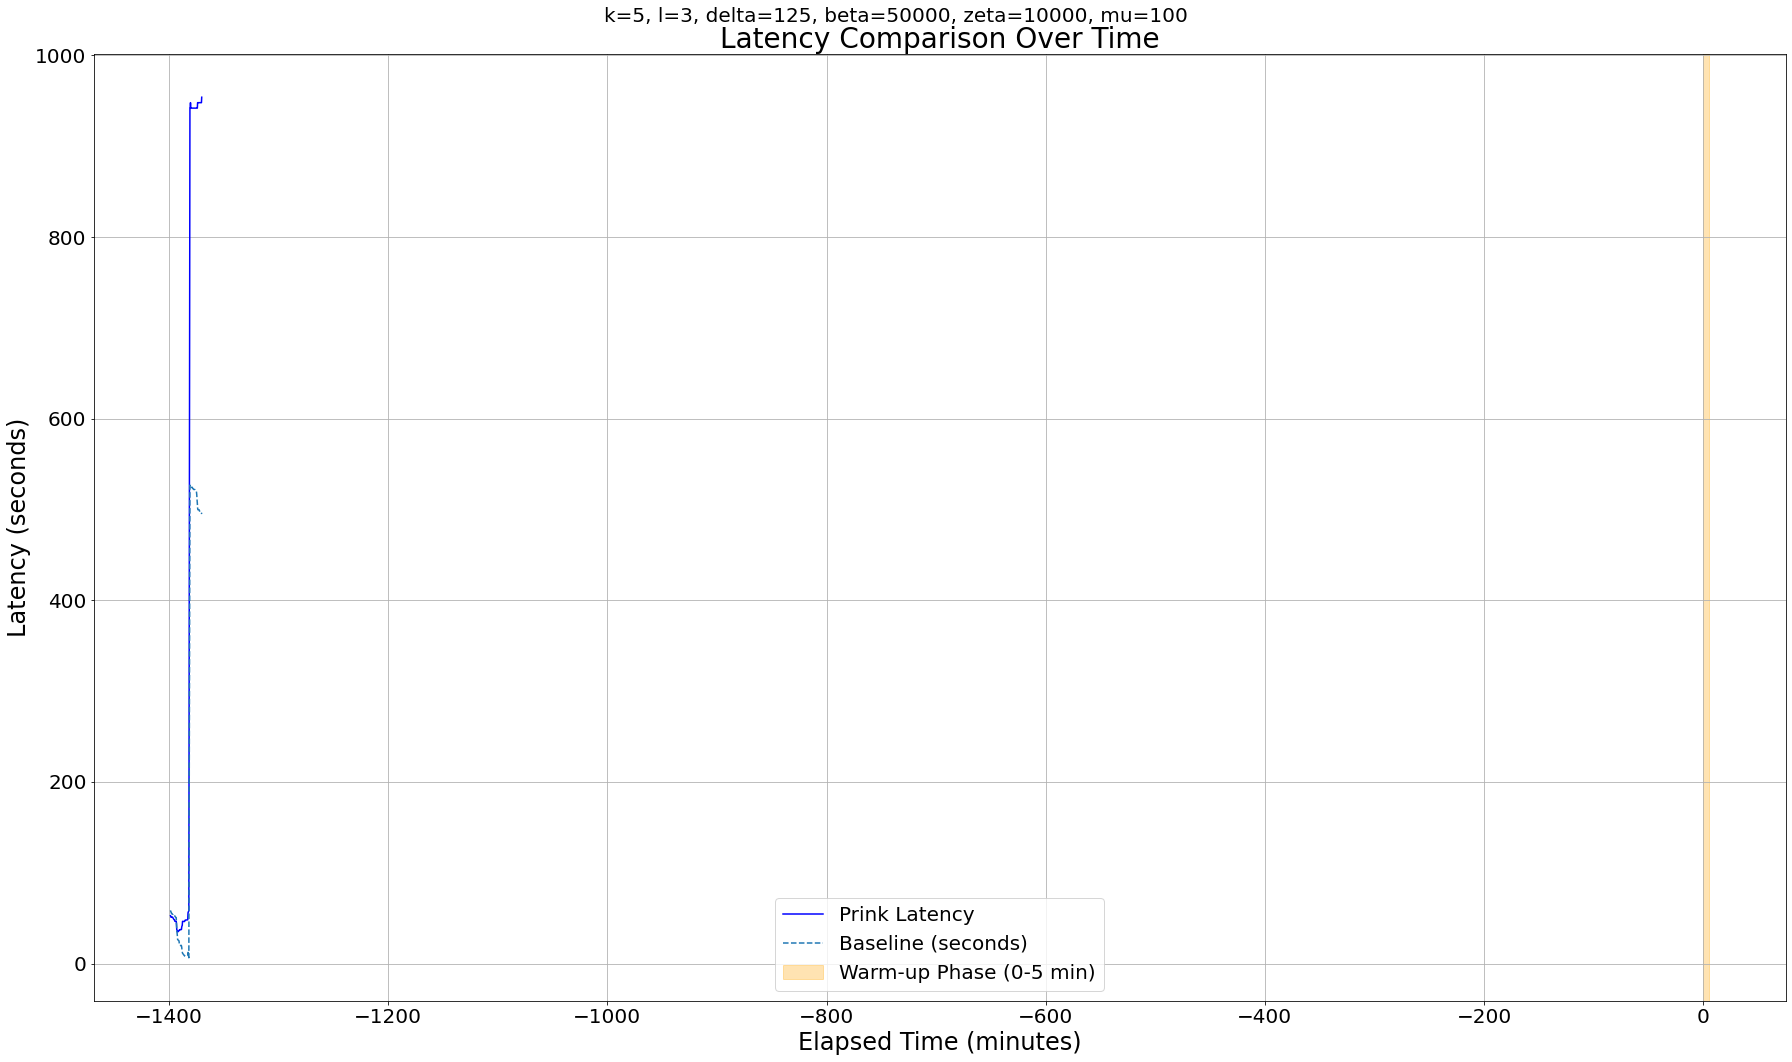

In [ ]:
plot_with_warmup_minutes(
    df_latency["Elapsed Minutes"],
    df_latency["Prink Latency"],
    "Latency (seconds)",
    "Latency Comparison Over Time",
    baseline=df_latency["Baseline Latency"],
    color="blue"
)





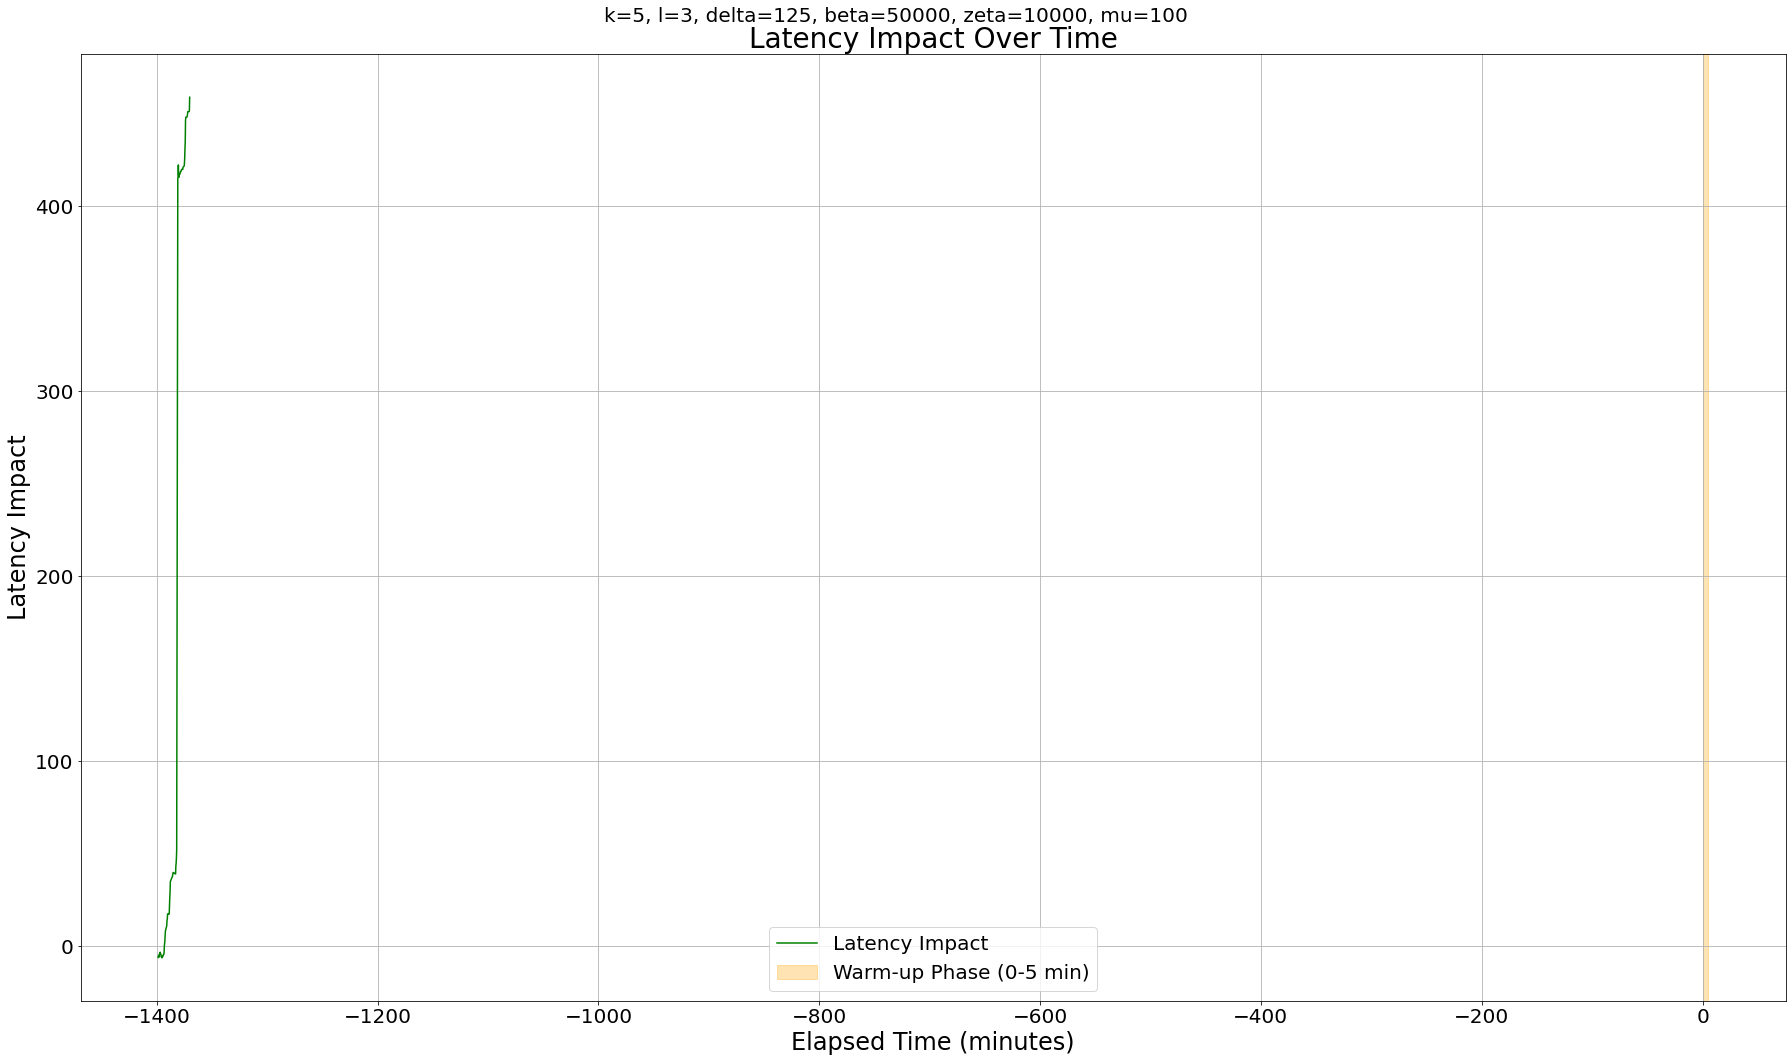

In [ ]:

plot_with_warmup_minutes_defined(df_latency["Elapsed Minutes"], df_latency["Latency Impact"], "Latency Impact", "Latency Impact Over Time", color="green")


In [ ]:

def plot_all_latencies_with_overhead(x, prink_latency, baseline_latency, latency_impact, warmup_minutes=5):
    plt.figure(figsize=(20, 10))
    
    # Plot Prink Latency
    plt.plot(x, prink_latency, label="Prink Latency", color="blue")
    
    # Plot Baseline Latency
    plt.plot(x, baseline_latency, label="Baseline Latency", linestyle="--", color="black")
    
    # Plot Latency Impact (Overhead)
    plt.plot(x, latency_impact, label="Latency Impact", color="green")
    # Fill under Latency Impact
    plt.fill_between(x, latency_impact, color="green", alpha=0.3)
    # Highlight Warm-up Phase
    plt.axvspan(0, warmup_minutes, color='orange', alpha=0.3, label=f"Warm-up Phase (0-{warmup_minutes} min)")
    
    # Labels and Title
    plt.title("Latency and Overhead", fontsize=28)
    # smaller subtitle including parameters
    k = params_k.get("k", "N/A")
    l = params_k.get("l", "N/A")
    d = params_k.get("d", "N/A")
    beta = params_k.get("beta", "N/A")
    zeta = params_k.get("zeta", "N/A")
    mu = params_k.get("mu", "N/A")
    plt.suptitle(f"k={k}, l={l}, delta={d}, beta={beta}, zeta={zeta}, mu={mu}", fontsize=20)

    plt.xlabel("Elapsed Time (minutes)", fontsize=24)
    plt.ylabel("Latency (seconds)", fontsize=24)
    
    # Styling
    plt.legend(fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    
    plt.show()

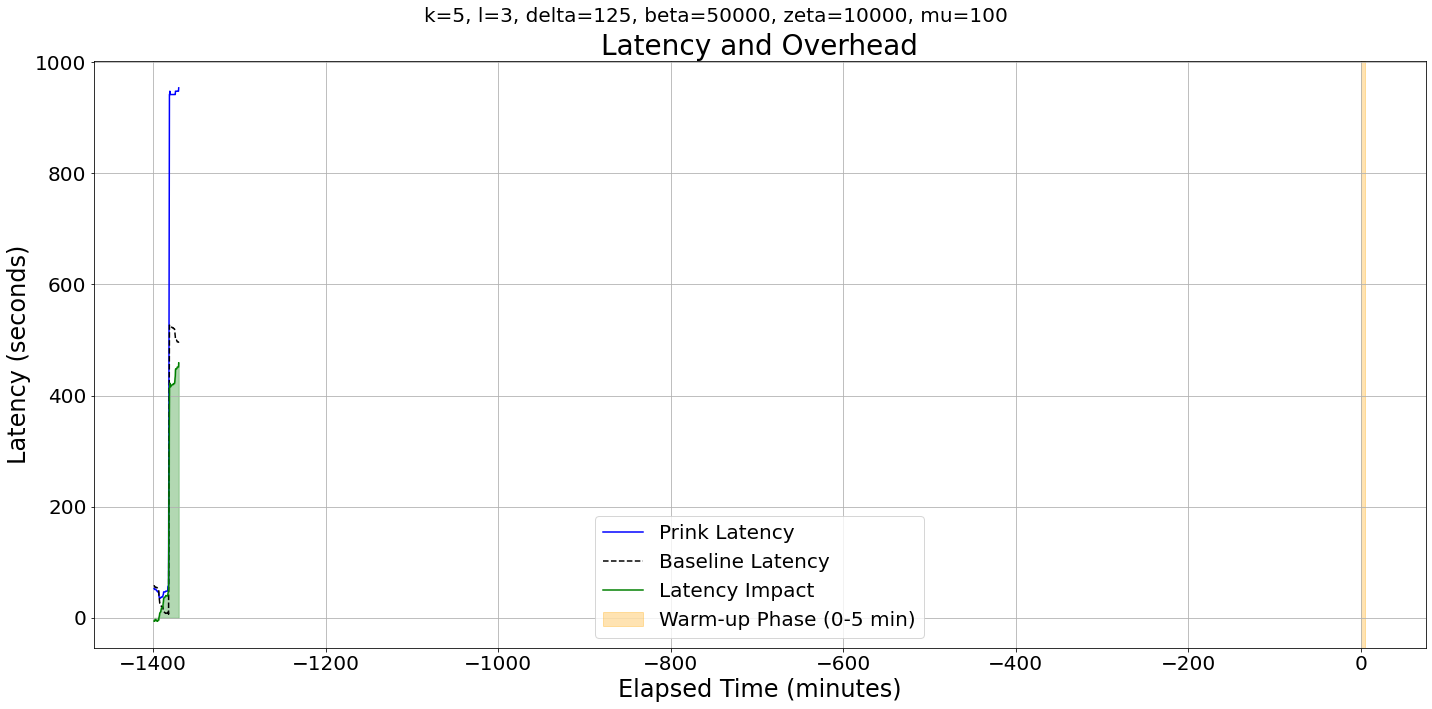

In [ ]:
plot_all_latencies_with_overhead(
    df_latency["Elapsed Minutes"],
    df_latency["Prink Latency"],
    df_latency["Baseline Latency"],
    df_latency["Latency Impact"],
    warmup_minutes=5
)

# Both privacy parameter in one plot

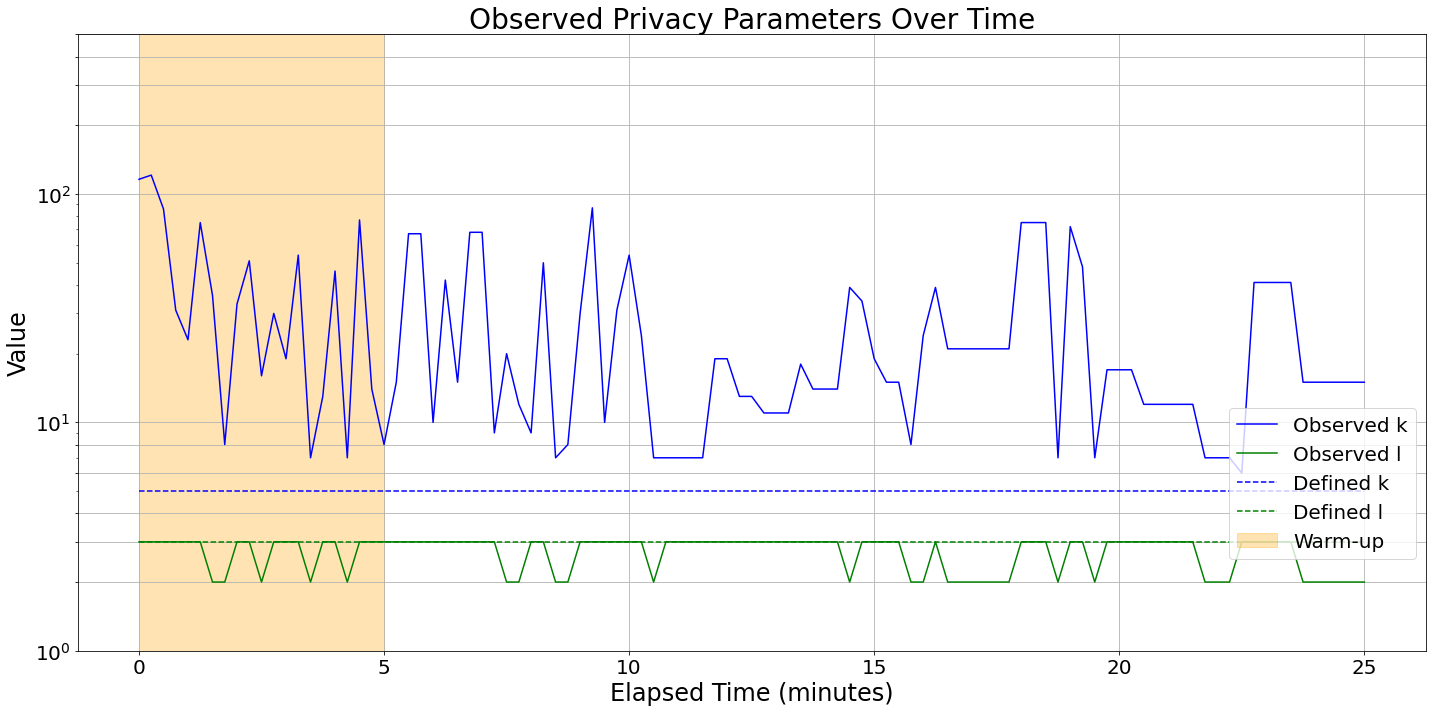

In [ ]:
# Warm-up threshold in minutes
warmup_minutes = 5

# Plot observed and defined values for both privacy metrics
plt.figure(figsize=(20, 10))

# Observed values
plt.plot(df_k["Elapsed Minutes"], df_k["Observed k"], label="Observed k", color="blue")
plt.plot(df_l["Elapsed Minutes"], df_l["Observed l"], label="Observed l", color="green")

# Defined values
plt.plot(df_k["Elapsed Minutes"], df_k["Defined k"], label="Defined k", color="blue", linestyle="--")
plt.plot(df_l["Elapsed Minutes"], df_l["Defined l"], label="Defined l", color="green", linestyle="--")

# Warm-up phase shading
plt.axvspan(0, warmup_minutes, color='orange', alpha=0.3, label="Warm-up")

# Titles and axis labels
plt.title("Observed Privacy Parameters Over Time", fontsize=28)
plt.xlabel("Elapsed Time (minutes)", fontsize=24)
plt.ylabel("Value", fontsize=24)
plt.yscale('log') 
# Legend (slightly moved down)
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.41), fontsize=20)

# Grid and ticks
plt.grid(True)
plt.xticks(fontsize=20)
plt.yticks([1, 2, 3, 4, 6, 8, 10, 100, 200, 300, 400, 500], fontsize=20)

plt.tight_layout()
plt.show()


# Calculate key performance metrics

In [ ]:
# Convert latency columns to float
df_latency["Baseline Latency"] = pd.to_numeric(df_latency["Baseline Latency"], errors="coerce")
df_latency["Prink Latency"] = pd.to_numeric(df_latency["Prink Latency"], errors="coerce")

# Recalculate elapsed time
df_latency["Time"] = pd.to_datetime(df_latency["Time"])
start_time = df_latency["Time"].min()
df_latency["Elapsed Seconds"] = (df_latency["Time"] - start_time).dt.total_seconds()

# Filter post-warm-up data
df_post_warmup = df_latency[df_latency["Elapsed Seconds"] > 300].copy()

# Compute overhead
df_post_warmup["Latency Overhead"] = df_post_warmup["Prink Latency"] - df_post_warmup["Baseline Latency"]

# Calculate metrics
latency_metrics_post_warmup = {
    "Baseline Mean Latency": df_post_warmup["Baseline Latency"].mean(),
    "Baseline Latency Std Dev": df_post_warmup["Baseline Latency"].std(),
    "Prink Mean Latency": df_post_warmup["Prink Latency"].mean(),
    "Prink Latency Std Dev": df_post_warmup["Prink Latency"].std(),
    "Average Overhead Introduced by Prink": df_post_warmup["Latency Overhead"].mean(),
    "Maximum Overhead": df_post_warmup["Latency Overhead"].max(),
    "Minimum Overhead": df_post_warmup["Latency Overhead"].min(),
    "Overhead Std Dev": df_post_warmup["Latency Overhead"].std()
}

# Show results
for k, v in latency_metrics_post_warmup.items():
    print(f"{k}: {v:.2f} s")

Baseline Mean Latency: 280.31 s
Baseline Latency Std Dev: 249.84 s
Prink Mean Latency: 518.60 s
Prink Latency Std Dev: 453.74 s
Average Overhead Introduced by Prink: 238.30 s
Maximum Overhead: 459.00 s
Minimum Overhead: -4.00 s
Overhead Std Dev: 204.75 s
